# Predikcija unapredjenja zaposlenih primenom tehnika masinskog ucenja

Cilj projekta je primena masinskog ucenja za predvidjanje unapredjenja zaposlenih na osnovu njihovih demografskih i profesionalnih karakteristika. Problem je formulisan kao zadatak binarne klasifikacije, gde ciljno obelezje oznacava da li je zaposleni unapredjen ili ne. Primenom tehnika masinskog ucenja nastojimo da otkrijemo obrasce u podacima i identifikujemo kljucne faktore koji uticu na unapredjenje. 

In [181]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

### Koriscene biblioteke

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

%matplotlib inline

## Ucitavanje i opis podataka 

Ucitavanje podataka i prikaz osnovnih informacija

In [183]:
df = pd.read_csv('data/train.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


Skup podataka cini 54808 zapisa sa 13 atributa i sadrzi demografske i profesionalne informacije o zaposlenima, kao i ciljno obelezje `is_promoted` koje oznacava da li je zaposleni unapredjen. Prisutan je veci broj numerickih i kategorijskih atributa, sto zahteva odgovarajuce pretprocesiranje pre primene modela masinskog ucenja.

### Kvalitet podataka
Pre dalje analize i modelovanja, neophodno je proveriti kvalitet podataka, ukljucujuci prisustvo nedostajucih vrednosti i eventualnih duplikata.

In [184]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [185]:
df.duplicated().sum()

np.int64(0)

Primetno je prisustvo nedostajucih vrednosti atributa `education` i `previous_year_rating`, sto zahteva primenu odgovarajucih tehnika imputacije u fazi pretprocesiranja. Skup podataka ne sadrzi duplikate.

### Analiza ciljne promenljive
U ovoj sekciji se nalazi analiza raspodele ciljne promenljive `is_promoted`. Razumevanje odnosa izmedju klasa je kljucno za izbor odgovarajucih tehnika balansiranja podataka i evaluacije modela.

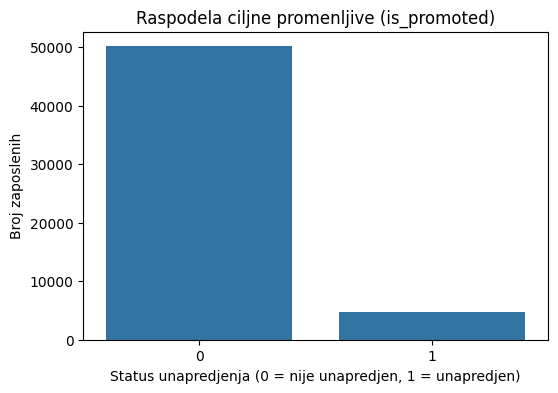

is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64

In [186]:
plt.figure(figsize=(6, 4))
sns.countplot(x="is_promoted", data=df)
plt.title("Raspodela ciljne promenljive (is_promoted)")
plt.xlabel("Status unapredjenja (0 = nije unapredjen, 1 = unapredjen)")
plt.ylabel("Broj zaposlenih")
plt.show()
df['is_promoted'].value_counts(normalize=True) * 100

Analiza raspodele ciljne promenljive pokazuje izrazenu nebalansiranost klasa, pri cemu znatno veci broj zaposlenih nije unapredjen u odnosu na one koji jesu. Ovakva struktura podataka moze dovesti do toga da modeli favorizuju vecinsku klasu.
Zbog toga ce u nastavku rada biti primenjena SMOTE tehnika za balansiranje podataka iskljucivo nad trening skupom, dok ce se kao glavna metrika za evaluaciju performansi koristiti F1-score, koji daje uravnotezenu meru izmedju preciznosti i odziva i omogucava realniju procenu performansi modela u ovakvim uslovima.

## Eksplorativna analiza relevantnih atributa
U ovoj sekciji je prikazana analiza atributa za koje se na osnovu domenskog znanja i preliminarne analize, može ocekivati da imaju znacajan uticaj na unapredjenje zaposlenih. Cilj ove analize je identifikacija potencijalno relevantnih faktora za dalje modelovanje.

## Uticaj profesionalnih atributa 

### Prethodna ocena rada

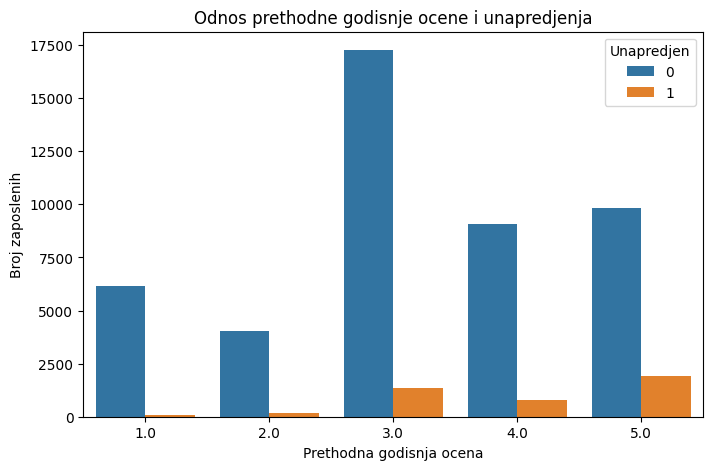

In [187]:
plt.figure(figsize=(8, 5))
sns.countplot(x="previous_year_rating", hue="is_promoted", data=df)
plt.title("Odnos prethodne godisnje ocene i unapredjenja")
plt.xlabel("Prethodna godisnja ocena")
plt.ylabel("Broj zaposlenih")
plt.legend(title="Unapredjen")
plt.show()

Uocava se jasna povezanost izmedju vise prethodne godisnje ocene i vece verovatnoce unapredjenja, sto ukazuje da je ovaj atribut jedan od kljucnih faktora u procesu donosenja odluka o unapredjenju.

### Rezultat obuke

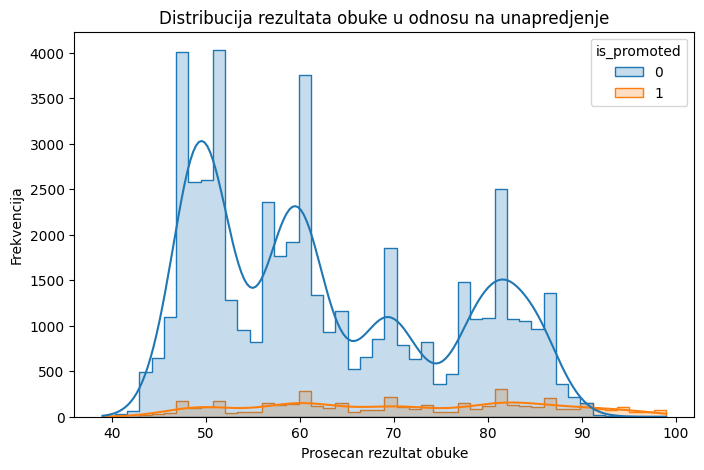

In [188]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="avg_training_score", hue="is_promoted", kde=True, element="step")
plt.title("Distribucija rezultata obuke u odnosu na unapredjenje")
plt.xlabel("Prosecan rezultat obuke")
plt.ylabel("Frekvencija")
plt.show()

Zaposleni sa visim rezultatima obuka imaju vecu ucestalost unapredjenja, sto potvrdjuje znacaj kontinuiranog usavrsavanja u procesu napredovanja.

### Nagrade

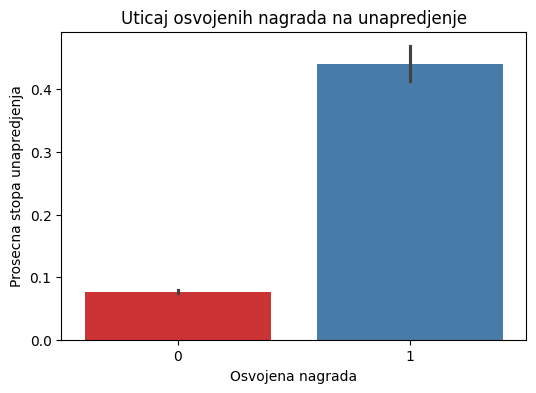

In [189]:
plt.figure(figsize=(6, 4))
sns.barplot(x="awards_won?", y="is_promoted", data=df, hue="awards_won?", palette="Set1", legend=False)
plt.title("Uticaj osvojenih nagrada na unapredjenje")
plt.xlabel("Osvojena nagrada")
plt.ylabel("Prosecna stopa unapredjenja")
plt.show()

Zaposleni koji su osvojili nagrade imaju znatno vecu prosecnu stopu unapredjenja, sto ukazuje na snazan pozitivan uticaj ovog atributa.

### Godine radnog staza

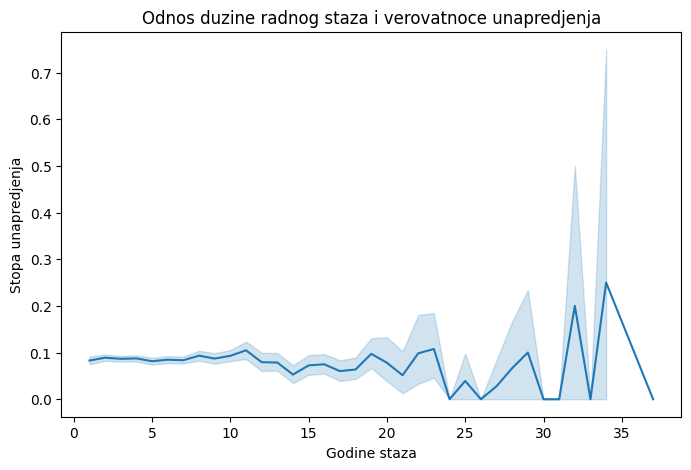

In [190]:
plt.figure(figsize=(8, 5))
sns.lineplot(x="length_of_service", y="is_promoted", data=df)
plt.title("Odnos duzine radnog staza i verovatnoce unapredjenja")
plt.xlabel("Godine staza")
plt.ylabel("Stopa unapredjenja")
plt.show()

Verovatnoca unapredjenja raste sa godinama staza do odredjene tacke, nakon cega se stabilizuje, sto ukazuje na nelinearnu zavisnost ovog atributa.

Na osnovu selektivne eksplorativne analize moze se zakljuciti da atributi kao sto su prethodna godisnja ocena, rezultati obuka, osvojene nagrade i duzina radnog staza imaju znacajan uticaj na verovatnocu unapredjenja.

## Demografski faktori

### Starost

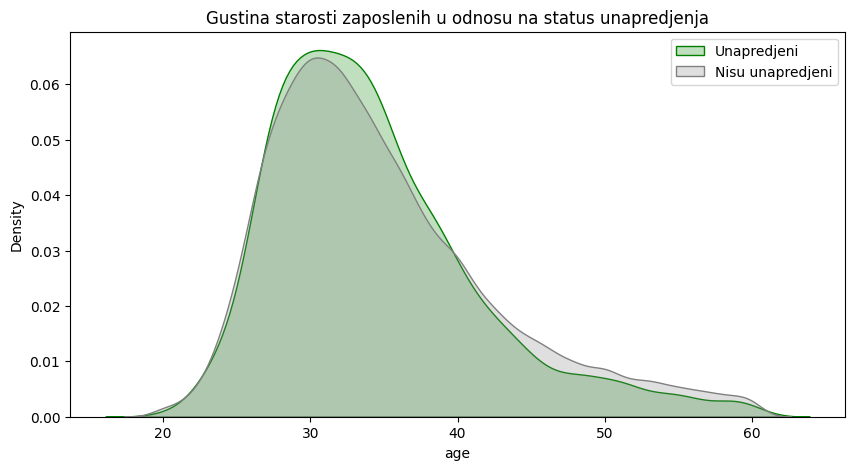

In [191]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['is_promoted'] == 1], x='age', label='Unapredjeni', fill=True, color='green')
sns.kdeplot(data=df[df['is_promoted'] == 0], x='age', label='Nisu unapredjeni', fill=True, color='grey')
plt.title('Gustina starosti zaposlenih u odnosu na status unapredjenja')
plt.legend()
plt.show()

### Pol

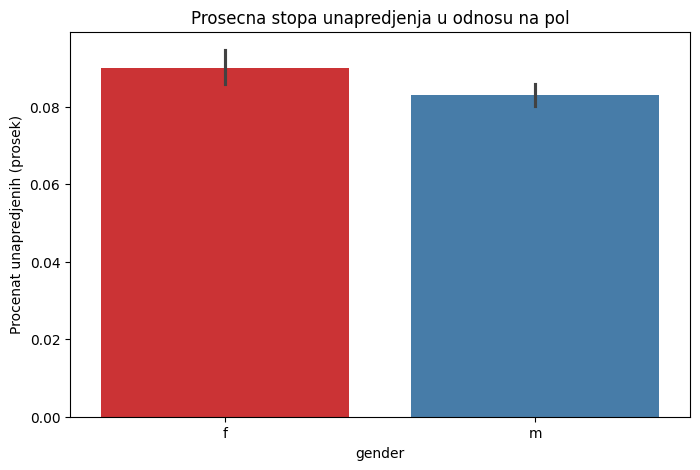

In [192]:
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='is_promoted', data=df, hue='gender', palette='Set1', legend=False)
plt.title('Prosecna stopa unapredjenja u odnosu na pol')
plt.ylabel('Procenat unapredjenih (prosek)')
plt.show()

### Obrazovanje

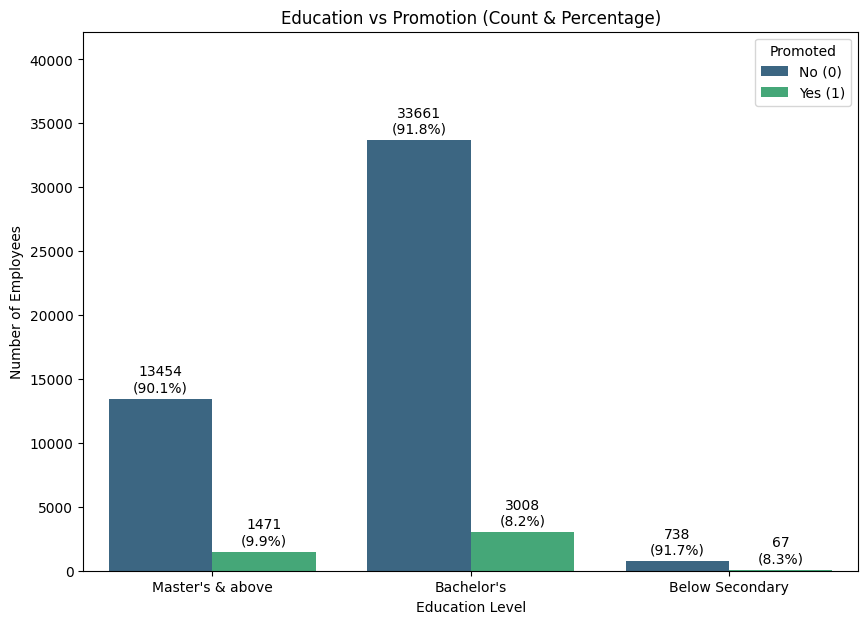

In [193]:
plt.figure(figsize=(10, 7))
ax = sns.countplot(x="education", hue="is_promoted", data=df, palette='viridis')

total_per_edu = df.groupby('education').size()
edu_order = [label.get_text() for label in ax.get_xticklabels()]

for container in ax.containers:
    labels = []
    for i, v in enumerate(container):
        count = v.get_height()
        if count > 0:
            edu_name = edu_order[i]
            total = total_per_edu[edu_name]
            percentage = (count / total) * 100
            labels.append(f'{int(count)}\n({percentage:.1f}%)')
        else:
            labels.append('0 (0.0%)')
    
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title("Education vs Promotion (Count & Percentage)")
plt.xlabel("Education Level")
plt.ylabel("Number of Employees")
plt.legend(title='Promoted', labels=['No (0)', 'Yes (1)'])
plt.ylim(0, df['education'].value_counts().max() * 1.15)
plt.show()

Analiza demografskih atributa ukazuje da starost, nivo obrazovanja i pol pokazuju odredjene razlike u stopama unapredjenja, ali bez izrazitih diskontinuiteta izmedju grupa. U poredjenju sa profesionalnim atributima, njihov uticaj deluje slabije izrazen. Iz tog razloga, demografski faktori ce biti ukljuceni u dalje modelovanje, ali se ne ocekuje da imaju dominantan doprinos u predikciji unaprecjenja.

---

# Pretprocesiranje podataka

## Definisanje ulaznih i izlazne promenljive

Cilj modela je predvidjanje da li je zaposleni unapredjen, sto predstavlja vrednost ciljne promenljive `is_promoted`. Svi ostali atributi predstavljaju ulazne promenljive na osnovu kojih modeli uce obrasce.

Pre pretprocesiranja se vrsi razdvajanje ulaza i izlaza da bi se izbeglo nenamerno koriscenje ciljne promenljive u imputaciji i transformacijama i da bi se omogucila pravilna primena tehnika kao sto su SMOTE i skaliranje iskljucivo nad ulazima.

In [194]:
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

Na ovaj nacin su razdvojeni podaci koje modeli koriste za ucenje (`X`) i tacni odgovori (`y`), sto je neophodno za ispravno treniranje i evaluaciju modela.

## Uklanjanje neinformativnih atributa

Kolona `employee_id` predstavlja jedinstveni identifikator zaposlenog i ne sadrzi informaciju relevantnu za proces unapredjenja. Njeno zadrzavanje moze dovesti do laznih obrazaca, pa se uklanja iz daljeg razmatranja.

In [195]:
X = X.drop('employee_id', axis=1)

Uklanjanjem identifikatora sprecava se da modeli uce irelevantne ili slucajne obrasce.

## Podela podataka na trening i test skup

Podaci se dele u odnosu 70:30, pri cemu se:
- trening skup koristi za ucenje i optimizaciju modela,
- test skup cuva netaknut za konacnu evaluaciju.

Stratifikacija po ciljnoj promenljivoj se koristi zbog izrazene klasne neravnoteze.

In [196]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [197]:
# dimenzije podataka pre imputacije, test ostaje nepromenjen
print("X_train_res shape:", X_train.shape)
print("y_train_res shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_res shape: (38365, 11)
y_train_res shape: (38365,)
X_test shape: (16443, 11)
y_test shape: (16443,)


Ovim pristupom obezbedjena je objektivna procena performansi modela.

## Razdvajanje numerickih i kategorijskih atributa

Razlicite vrste atributa zahtevaju razlicite tehnike pretprocesiranja:
- numericki atributi zahtevaju imputaciju i skaliranje
- kategorijski atributi zahtevaju imputaciju i kodiranje
- edukacija, iako kategorijski atribut, je izdvojena zbog posebne obrade

Zbog toga se atributi razdvajaju po tipu.

In [198]:
num_cols = [
    'age',
    'no_of_trainings',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score',
    'awards_won?'
]

cat_cols = [
    'department',
    'region',
    'gender',
    'recruitment_channel'
]

education = [
    'education'
]

In [199]:
print(X_train['education'].unique())

["Bachelor's" "Master's & above" nan 'Below Secondary']


Ova podela omogucava obradu podataka uskladjenu sa tipom.

## Imputacija nedostajucih vrednosti

S obzirom na umeren procenat nedostajucih vrednosti, podaci nisu uklanjani.
Primenjena je kontrolisana imputacija:
- numericke vrednosti zamenjuju se medianom,
- kategorijske vrednosti se zamenjuju novom kategorijom 'Unknown'.

In [200]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

X_train[['education']] = cat_imputer.fit_transform(X_train[['education']])
X_test[['education']] = cat_imputer.transform(X_test[['education']])

Upotrebom metoda fit_transform() na trening skupom i transform() nad test skupom odradjena je imputacija nedostajucih vrednosti, a ovaj pristup sprecava curenje informacija iz test skupa.

## Kodiranje kategorijskih atributa

Za kodiranje kategorijskih atributa promenjena je One-Hot Encoding metoda, pri cemu se svaka kategorija transformise u binarnu promenjivu, cime se izbegava uvodjenje vestackog redosleda izmedju kategorija, sto je vazno za modele koji pretpostavljaju linearnu zavisnost izmedju ulaznih promenjivih i ciljne promenjive kao sto radi logisticka regresija. 


Atribut education nije kodiran One-Hot metodom, već ordinalnim kodiranjem, jer poseduje prirodan redosled nivoa obrazovanja (Other < Bachelor's < Master's & above). Kategorija 'Unknown' mapirana je na najniži nivo, jer predstavlja nedostajuće ili nedefinisane vrednosti.

In [201]:
education_mapping = {
    'Other': 0,
    'Unknown': 0,
    'Below Secondary': 0,
    "Bachelor's": 1,
    "Master's & above": 2
}

X_train['education'] = X_train['education'].map(education_mapping)
X_test['education'] = X_test['education'].map(education_mapping)

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Nakon kodiranja uradjeno je uskladjivanje trening i test skupa kako bi oba skupa imala identicnu strukturu kolona, zbog omogucavanja konzistentnosti ulaznih podataka tokom treninga i evaluacije.

In [202]:
print(X_train.isnull().sum().sum())  
print(X_test.isnull().sum().sum()) 

0
0


## Korelaciona matrica

U cilju ispitivanja međusobnih odnosa između numeričkih atributa, izračunata je korelaciona matrica.

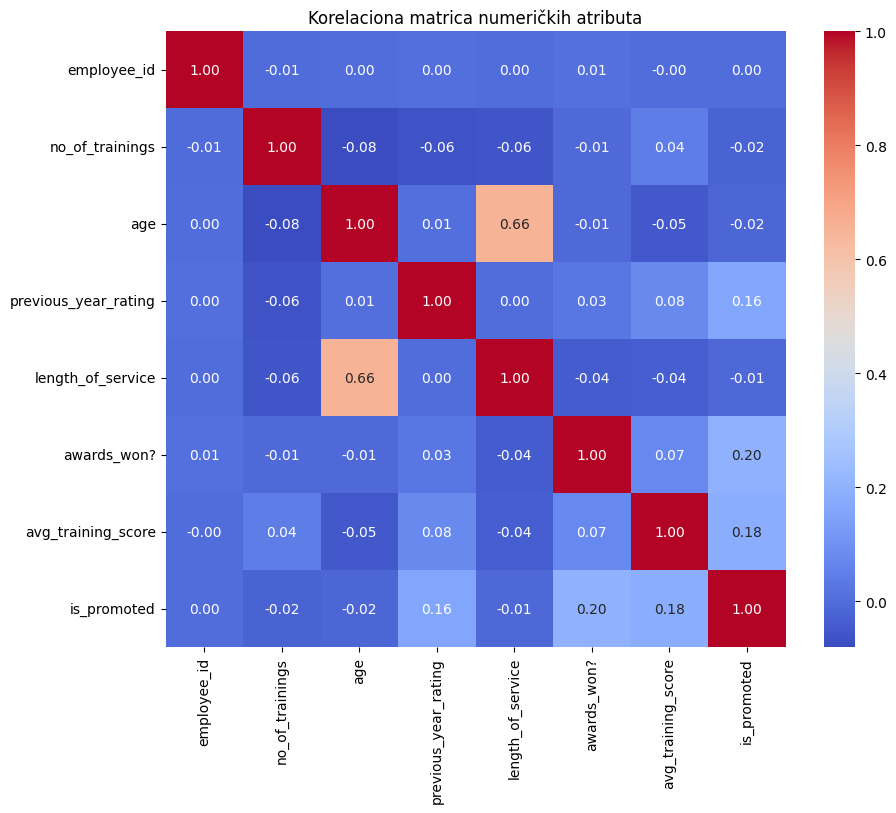

In [203]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelaciona matrica numeričkih atributa")
plt.show()

Na osnovu prikazane matrice može se uočiti da većina atributa nema jaku međusobnu korelaciju, što ukazuje na nizak stepen multikolinearnosti. Najizraženije veze primećuju se između pojedinih profesionalnih atributa i ciljne promenljive, posebno kod atributa previous_year_rating, avg_training_score i awards_won? što dodatno potvrđuje njihov značaj u procesu predikcije unapređenja.

Kako bi se ispitala povezanost kategorijskih atributa sa ciljnom promenljivom, izvršeno je njihovo kodiranje u numerički oblik, nakon čega je izračunata korelaciona matrica.

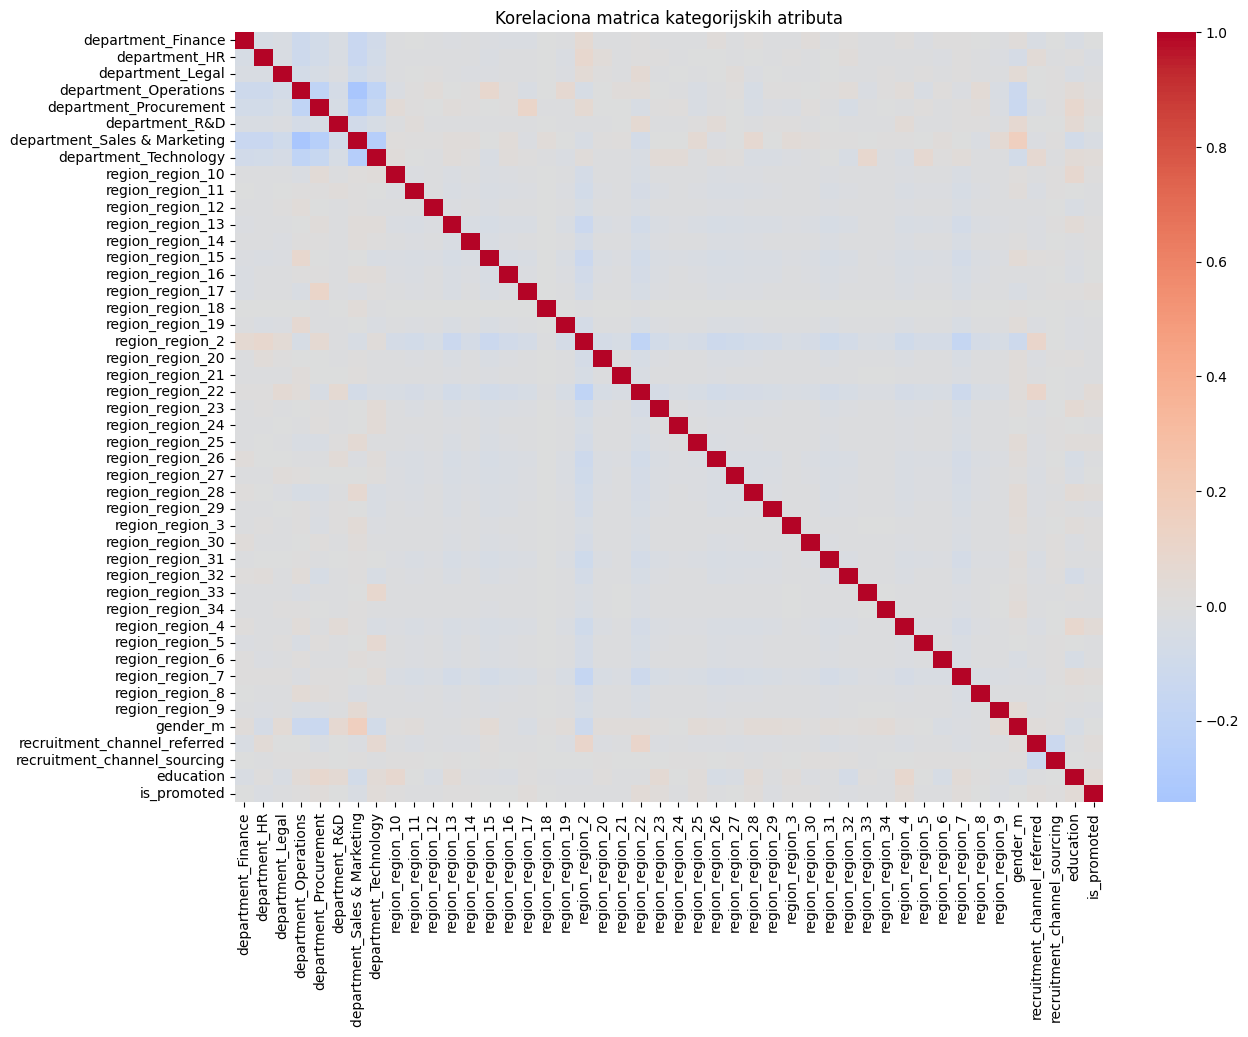

In [204]:
cat_encoded_cols = [col for col in X_train.columns if any(c in col for c in cat_cols)]

cat_encoded_cols.append('education')

corr_df = X_train[cat_encoded_cols].copy()
corr_df['is_promoted'] = y_train.values

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0)
plt.title("Korelaciona matrica kategorijskih atributa")
plt.show()

In [205]:
corr_target = corr_df.corr()['is_promoted'].sort_values(ascending=False)
print(corr_target.head(10))

is_promoted                     1.000000
region_region_22                0.039725
region_region_4                 0.036064
education                       0.034970
department_Technology           0.028986
region_region_25                0.021786
recruitment_channel_referred    0.020998
region_region_7                 0.020079
region_region_23                0.019019
region_region_17                0.018820
Name: is_promoted, dtype: float64


Kada pogledamo korelaciju kodiranih kategorijskih atributa sa is_promoted, nijedna kategorija nema jako izražen uticaj, što znači da nijedna sama po sebi ne može predvideti unapređenje. Ipak, primećuje se da određene regije (poput region_22 i region_4), nivo obrazovanja i odeljak Technology imaju nešto veću korelaciju, što sugeriše da u tim grupama zaposlenih postoji nešto veća verovatnoća da budu unapređeni. 

## Skaliranje numerickih atributa

Skaliranje se primenjuje zbog logisticke regresije, koja je osetljiva na razlicite razmere atributa. Za modele zasnovane na stablima skaliranje nije neophodno, ali se zadrzava radi konzistentnosti.

In [206]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Skalirani podaci omogucavaju stabilnije i uporedive rezultate modela.

## Balansiranje klasa

Zbog izražene neravnoteže u ciljnoj promenljivoj, gde samo oko 9% zaposlenih pripada klasi unapređenih, primena tehnika balansiranja podataka predstavlja ključan korak u procesu modelovanja.

U ovom radu primenjene su tri različite metode balansiranja:
- **SMOTE** (Synthetic Minority Over-sampling Technique) – generiše nove sintetičke uzorke manjinske klase
- **ROS** (Random OverSampling) – nasumično duplira postojeće uzorke manjinske klase
- **SMOTE-Tomek** (SMOTE + Tomek Links) – kombinuje generisanje novih uzoraka sa uklanjanjem preklapajućih instanci između klasa

Cilj je ispitati kako razlicite tehnike balansiranja uticu na performanse modela, sto ce biti mereno uporedjivanjem f1-score.
Zbog izrazene klasne neravnoteze, tehnike se primenjuju iskljucivo nad trening skupom kako bi se sprecilo curenje informacija iz test skupa.

In [207]:
#SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [208]:
#ROS
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [209]:
# SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

Na ovaj nacin modeli dobijaju uravnotezen trening skup, dok test skup ostaje nepromenjen.

### Provera dimenzija podataka nakon pretprocesiranja

In [210]:
print("SMOTE:")
print("X_train_smote shape:", X_train_smote.shape)
print("y_train_smote shape:", y_train_smote.shape, "\n")

print("Random OverSampling:")
print("X_train_ros shape:", X_train_ros.shape)
print("y_train_ros shape:", y_train_ros.shape, "\n")

print("SMOTE-Tomek:")
print("X_train_st shape:", X_train_st.shape)
print("y_train_st shape:", y_train_st.shape, "\n")

print("Test skup:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

SMOTE:
X_train_smote shape: (70194, 51)
y_train_smote shape: (70194,) 

Random OverSampling:
X_train_ros shape: (70194, 51)
y_train_ros shape: (70194,) 

SMOTE-Tomek:
X_train_st shape: (69888, 51)
y_train_st shape: (69888,) 

Test skup:
X_test shape: (16443, 51)
y_test shape: (16443,)


Broj redova u trening skupovima je povecan zbog primene tehnika balansiranja. Nakon primene SMOTE-Tomek metode dolazi do blagog smanjenja broja uzoraka u odnosu na SMOTE i ROS, jer se nakon generisanja dodatnih uzoraka uklanjaju Tomek linkovi, odnosno primeri koji se nalaze na granici izmedju klasa i mogu predstavljati sum ili preklapanje klasa.

Test skup je ostao nepromenjen da bi se zadrzala distribucija klasa. 

### Provera balansiranosti klasa u trening skupu

Provera raspodela ciljnih klasa u trening skupu nakon primene SMOTE tehnike.

In [211]:
print("Raspodela klasa u SMOTE trening skupu (%):")
print(pd.Series(y_train_smote).value_counts(normalize=True) * 100)

print("\nRaspodela klasa u ROS trening skupu (%):")
print(pd.Series(y_train_ros).value_counts(normalize=True) * 100)

print("\nRaspodela klasa u SMOTE-Tomek trening skupu (%):")
print(pd.Series(y_train_st).value_counts(normalize=True) * 100)

Raspodela klasa u SMOTE trening skupu (%):
is_promoted
0    50.0
1    50.0
Name: proportion, dtype: float64

Raspodela klasa u ROS trening skupu (%):
is_promoted
0    50.0
1    50.0
Name: proportion, dtype: float64

Raspodela klasa u SMOTE-Tomek trening skupu (%):
is_promoted
0    50.0
1    50.0
Name: proportion, dtype: float64


Trening skup je balansiran.

### Provera da nema nedostajucih vrednosti

In [212]:
print("Nedostajuće vrednosti u test skupu:")
print("X_test:", X_test.isnull().sum().sum())
print("y_test:", pd.Series(y_test).isnull().sum())
print()

print("Nedostajuće vrednosti u treninzima nakon balansiranja klasa:")

print("SMOTE:")
print("X_train_smote:", X_train_smote.isnull().sum().sum())
print("y_train_smote:", pd.Series(y_train_smote).isnull().sum())
print()

print("Random OverSampling:")
print("X_train_ros:", X_train_ros.isnull().sum().sum())
print("y_train_ros:", pd.Series(y_train_ros).isnull().sum())
print()

print("SMOTE-Tomek:")
print("X_train_st:", X_train_st.isnull().sum().sum())
print("y_train_st:", pd.Series(y_train_st).isnull().sum())

Nedostajuće vrednosti u test skupu:
X_test: 0
y_test: 0

Nedostajuće vrednosti u treninzima nakon balansiranja klasa:
SMOTE:
X_train_smote: 0
y_train_smote: 0

Random OverSampling:
X_train_ros: 0
y_train_ros: 0

SMOTE-Tomek:
X_train_st: 0
y_train_st: 0


## Uvid u konacni izgled podataka

Prikaz nekoliko prvih redova trening skupa koji predstavlja konacni format podataka koje modeli koriste za ucenje.

In [213]:
X_train_smote.head()

,education,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,department_Finance,department_HR,department_Legal,...,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,1,-0.416218,-1.017475,-0.253348,-0.437284,-0.153041,-0.850984,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,1,1.234584,0.414760,0.569448,0.973880,-0.153041,1.169258,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,-0.416218,-1.147679,-1.898941,-0.672478,-0.153041,-0.476865,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,1,-0.416218,-1.017475,-1.076144,-0.437284,-0.153041,-1.075455,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1,-0.416218,-0.887272,-0.253348,-0.907672,-0.153041,0.196549,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### Zakljucak pretprocesiranja podataka

U ovoj fazi podaci su pripremljeni za primenu algoritama masinskog ucenja na nacin koji obezbedjuje pouzdanost i objektivnost rezultata.

Izvrseno je razdvajanje ulaznih i izlazne promenljive, uklanjanje neinformativnih atributa, kao i imputacija nedostajucih vrednosti bez gubitka podataka. Kategorijski atributi su kodirani primenom One-Hot Encoding metode, dok su numericki atributi skalirani radi stabilnijeg
ponasanja modela. Zbog izražene klasne neravnoteže, nad trening skupom su primenjene tri različite tehnike balansiranja: SMOTE, Random OverSampling i SMOTE-Tomek, dok je test skup ostao neizmenjen kako bi se obezbedila realna procena performansi modela.

Na kraju ove faze imamo skupove:
- X_train_smote, y_train_smote – trening skup pripremljen i balansiran primenom SMOTE tehnike
- X_train_ros, y_train_ros – trening skup pripremljen i balansiran primenom Random OverSampling tehnike
- X_train_st, y_train_st – trening skup pripremljen i balansiran primenom SMOTE-Tomek tehnike
- `X_test` koji sadrzi pretprocesirane ulaze, potreban za evaluaciju
- `y_test` koji sadrzi prava resenja, potreban za evaluaciju

---

## Logisticka regresija - bazni model

Logisticka regresija se koristi kao bazni model za problem binarne klasifikacije unapredjenja zaposlenih.
U kontekstu ovog rada bazni model sluzi za postavljanje referentne tacke performansi i poredjenje sa slozenijim nelinearnim modelima.

Model se trenira na prethodno balansiranom trening skupu. 
U cilju izbora optimalne tehnike balansiranja, modeli su trenirani nad tri varijante trening skupa(SMOTE, ROS i SMOTE-Tomek).

In [214]:
# SMOTE
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)


# ROS
log_reg_ros = LogisticRegression(max_iter=1000, random_state=42)
log_reg_ros.fit(X_train_ros, y_train_ros)


# SMOTE-Tomek
log_reg_st = LogisticRegression(max_iter=1000, random_state=42)
log_reg_st.fit(X_train_st, y_train_st)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Evaluacija baznog modela

Evaluacija modela se vrsi na originalnom test skupu koji zadrzava realnu distribuciju klasa od oko 9% unapredjenih zaposlenih. Zbog klasne neravnoteze, kao glavna metrika koristi se F1-score, uz prikaz preciznosti i odziva.

In [215]:
# SMOTE
y_pred_smote = log_reg_smote.predict(X_test)

# ROS
y_pred_ros = log_reg_ros.predict(X_test)

# SMOTE-Tomek
y_pred_st = log_reg_st.predict(X_test)

results_lr = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_ros),
        precision_score(y_test, y_pred_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_ros),
        recall_score(y_test, y_pred_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_ros),
        f1_score(y_test, y_pred_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_ros),
        accuracy_score(y_test, y_pred_st)
    ]
})

print(results_lr)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.270134  0.534286  0.358839  0.837438
1          ROS   0.212045  0.666429  0.321724  0.760749
2  SMOTE-Tomek   0.271014  0.534286  0.359615  0.837986


Kod SMOTE i SMOTE-Tomek model prepoznaje više od polovine unapređenih zaposlenih (recall ≈ 0.53), ali uz nižu preciznost (~0.27), što znači da postoji veći broj pogrešno predloženih kandidata za unapređenje. ROS dodatno povećava recall, ali uz još lošiju preciznost, pa model postaje sklon preteranom označavanju zaposlenih kao unapređenih. U kontekstu projekta, model može pomoći u identifikaciji potencijalnih kandidata, ali zahteva dodatnu proveru rezultata. SMOTE-Tomek se izdvaja kao najbalansiranija opcija prema F1-score metrici.

## Random Forest

Random Forest je ansambl metoda zasnovana na stablima odlucivanja, koja je pogodna za modelovanje nelinearnih odnosa izmedju promenjivih i zbog svoje robusnosti protiv overfitting-a. 

Model se trenira na prethodno balansiranom trening skupu. Uporedićemo performanse modela na osnovu različitih tehnika balansiranja.

In [216]:
# SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)


# ROS
rf_ros = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_ros.fit(X_train_ros, y_train_ros)


# SMOTE-Tomek
rf_st = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_st.fit(X_train_st, y_train_st)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluacija Random Forest modela 

Evaluacija se vrsi na originalnom test skupu, gde je ocuvana realna distribucija klasa.

In [217]:
# SMOTE
y_pred_rf_smote = rf_smote.predict(X_test)

# ROS
y_pred_rf_ros = rf_ros.predict(X_test)

# SMOTE-Tomek
y_pred_rf_st = rf_st.predict(X_test)

results_rf = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_rf_smote),
        precision_score(y_test, y_pred_rf_ros),
        precision_score(y_test, y_pred_rf_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf_smote),
        recall_score(y_test, y_pred_rf_ros),
        recall_score(y_test, y_pred_rf_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_rf_smote),
        f1_score(y_test, y_pred_rf_ros),
        f1_score(y_test, y_pred_rf_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_smote),
        accuracy_score(y_test, y_pred_rf_ros),
        accuracy_score(y_test, y_pred_rf_st)
    ]
})

print(results_rf)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.505688  0.349286  0.413181  0.915526
1          ROS   0.643631  0.339286  0.444341  0.927750
2  SMOTE-Tomek   0.503553  0.354286  0.415933  0.915283


Odziv modela se kreće oko 0.35, što znači da Random Forest prepoznaje nešto više od trećine stvarno unapredjenih zaposlenih, nešto manje nego kod Logisticke regresije (0.54). Međutim, preciznost od 0.51–0.64 pokazuje da su pozitivne predikcije značajno pouzdanije nego kod LogReg, gde je preciznost bila 0.27. Visoka tačnost od oko 0.92–0.93 i dalje nije reprezentativna zbog neravnomerne raspodele klasa, zbog čega se fokus stavlja na F1-score. F1-score od 0.41–0.44 pokazuje da su performanse modela bolje izbalansirane između preciznosti i odziva u poređenju sa LogReg, što sugeriše da Random Forest daje pouzdanije pozitivne predikcije i bolje balansira lažno pozitivne i lažno negativne rezultate, posebno u kombinaciji sa ROS tehnikom balansiranja.

Moze se zakljuciti da Random Forest postize stabilnije i pouzdanije performanse u identifikaciji unapredjenih zaposlenih u odnosu na linearni model, sto je bilo ocekivano zbog njegove sposobnosti da modeluje nelinearne odnose izmadju promenjivih.

## Gradient Boosting

Gradient Boosting je ansambl metoda koja gradi sekvencijalno stabla odlučivanja, gde svako novo stablo ispravlja greške prethodnih, što omogućava precizno modelovanje složenih i nelinearnih odnosa između promenjivih.

Model se trenira na prethodno balansiranom trening skupu. Uporedićemo performanse modela na osnovu različitih tehnika balansiranja.

In [218]:
# SMOTE
gb_smote = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)
gb_smote.fit(X_train_smote, y_train_smote)

# ROS
gb_ros = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)
gb_ros.fit(X_train_ros, y_train_ros)

# SMOTE-Tomek
gb_st = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)
gb_st.fit(X_train_st, y_train_st)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Evaluacija Gradient Boosting modela

Evaluacija se vrsi na originalnom test skupu, gde je ocuvana realna distribucija klasa.

In [219]:
y_pred_gb_smote = gb_smote.predict(X_test)
y_pred_gb_ros = gb_ros.predict(X_test)
y_pred_gb_st = gb_st.predict(X_test)

# Evaluacija
results_gb = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_gb_smote),
        precision_score(y_test, y_pred_gb_ros),
        precision_score(y_test, y_pred_gb_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_gb_smote),
        recall_score(y_test, y_pred_gb_ros),
        recall_score(y_test, y_pred_gb_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_gb_smote),
        f1_score(y_test, y_pred_gb_ros),
        f1_score(y_test, y_pred_gb_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gb_smote),
        accuracy_score(y_test, y_pred_gb_ros),
        accuracy_score(y_test, y_pred_gb_st)
    ]
})

print(results_gb)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.489215  0.405000  0.443142  0.913337
1          ROS   0.274615  0.623571  0.381306  0.827708
2  SMOTE-Tomek   0.489601  0.403571  0.442443  0.913398


Gradient Boosting postiže uravnoteženije performanse u identifikaciji unapređenih zaposlenih u poređenju sa Logističkom regresijom, ali i u nekim aspektima slično Random Forest-u. Odziv modela varira između 0.40–0.62, gde ROS daje najveći odziv (0.62), ali uz nisku preciznost (0.27), što znači veliki broj lažno pozitivnih predikcija. SMOTE i SMOTE-Tomek daju bolju preciznost (~0.49) uz nešto niži odziv (~0.40), što rezultira boljim balansom između preciznosti i odziva. F1-score iznosi 0.44 za SMOTE i SMOTE-Tomek, dok ROS daje 0.38, što ukazuje da je najbolje balansirana kombinacija Gradient Boosting sa SMOTE tehnikom, slično kao što je Random Forest najbolje funkcionisao sa ROS-om. Tacnost (~0.91) opet nije pouzdana zbog nebalansirane distribucije klasa, pa se F1-score koristi kao glavna metrika evaluacije.

## XGBoost

XGBoost je ansambl metoda zasnovana na gradijentnom pojačavanju stabala odluka, koja kombinuje više slabih stabala kako bi dobila snažan prediktivni model i efikasno hvata nelinearne odnose između promenljivih, uz dobru kontrolu overfitting-a.

Model se trenira na prethodno balansiranom trening skupu. Uporedićemo performanse modela na osnovu različitih tehnika balansiranja.

In [220]:
# SMOTE
xgb_smote = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

# ROS
xgb_ros = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_ros.fit(X_train_ros, y_train_ros)

# SMOTE-Tomek
xgb_st = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_st.fit(X_train_st, y_train_st)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### Evaluacija XGBoost modela

Evaluacija se vrsi na originalnom test skupu, gde je ocuvana realna distribucija klasa.

In [221]:
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_pred_xgb_ros = xgb_ros.predict(X_test)
y_pred_xgb_st = xgb_st.predict(X_test)

results_xgb = pd.DataFrame({
    "Balancing": ["SMOTE", "ROS", "SMOTE-Tomek"],
    "Precision": [
        precision_score(y_test, y_pred_xgb_smote),
        precision_score(y_test, y_pred_xgb_ros),
        precision_score(y_test, y_pred_xgb_st)
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb_smote),
        recall_score(y_test, y_pred_xgb_ros),
        recall_score(y_test, y_pred_xgb_st)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_xgb_smote),
        f1_score(y_test, y_pred_xgb_ros),
        f1_score(y_test, y_pred_xgb_st)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb_smote),
        accuracy_score(y_test, y_pred_xgb_ros),
        accuracy_score(y_test, y_pred_xgb_st)
    ]
})

print(results_xgb)

     Balancing  Precision    Recall  F1-score  Accuracy
0        SMOTE   0.798107  0.361429  0.497542  0.937846
1          ROS   0.297071  0.557857  0.387689  0.849967
2  SMOTE-Tomek   0.793375  0.359286  0.494592  0.937481


XGBoost pokazuje slične trendove kao Random Forest, ali sa znatno većom preciznošću kada se koristi SMOTE ili SMOTE-Tomek, što znači da su pozitivne predikcije (stvarno unapređeni) mnogo pouzdanije. Odziv ostaje oko 0.36, što pokazuje da model identifikuje oko trećinu stvarno unapređenih, slično Random Forest-u. F1-score za SMOTE je 0.50, što predstavlja najbolje balansirane performanse između preciznosti i odziva među svim testiranim tehnikama, dok visoka tačnost od oko 0.94 opet ne odražava stvarnu sposobnost modela zbog neravnomerne raspodele klasa. Najbolji rezultat u ovom slučaju postiže kombinacija XGBoost + SMOTE, dok ROS daje niži F1-score (0.39), što ukazuje da ova tehnika balansiranja nije optimalna za ovaj ansambl model.

Upoređujući sve tri metode, XGBoost postiže najbolji balans između preciznosti i odziva, posebno u kombinaciji sa SMOTE tehnikom, dok Random Forest pokazuje stabilne i pouzdane performanse. Logistička regresija ima veći odziv, ali znatno nižu preciznost, što znači više lažno pozitivnih predikcija. Dakle, za ovaj skup podataka najbolje performanse daje XGBoost sa SMOTE, dok ROS generalno nije optimalna za nijedan od ansambl modela.

Na osnovu reaultata dobijenih primenom modela Logisticke regresije, Random Foresta, Gradient Boostinga i XGBoost modela nad trening skupovima nad kojima su upotrebljene SMOTE, ROS i SMOTE-Tomek tehnike resavanja nebalansiranosti, moze se zakljuciti da najbolji rezultat postize XGBoost + SMOTE.

# Grid Search + cross validation

U cilju unapredjenja performansi modela, izvrsena je optimizacija hiperparametara primenom Grid Search metode uz k-fold unakrsnu validaciju. Ovaj pristup omogucava ispitivanje razlicitih kombinacija parametara i izbor optimalnog modela na osnovu f1-score metrike.

In [222]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

best_xgb = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


### Evaluacija
Grid Search i SMOTE nad XGBoost

In [223]:
y_pred_best = best_xgb.predict(X_test)

print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))

Precision: 0.7769230769230769
Recall: 0.3607142857142857
F1: 0.4926829268292683


### Poredjenje pre i posle tuninga

In [224]:
f1_before = f1_score(y_test, y_pred_xgb_smote)
f1_after = f1_score(y_test, y_pred_best)

print("F1 pre tuninga:", f1_before)
print("F1 posle tuninga:", f1_after)

F1 pre tuninga: 0.4975417895771878
F1 posle tuninga: 0.4926829268292683


F1-score je pao nakon tuninga.
Iako je primenom Grid Search metode dobijen model sa optimalnim hiperparametrima na osnovu unakrsne validacije, performanse na test skupu nisu pokazale poboljšanje u odnosu na inicijalni model.
Ovo ukazuje na to da optimizacija može dovesti do blagog preprilagođavanja (overfitting-a) na trening skup, zbog čega inicijalni model zadržava bolje generalizacione sposobnosti.

nije neka razlika, nije unapredjno hahah

# Feature Importance
Analiza atributa da se indentifikuju kljucni faktori koji uticu na unapredjenje

previous_year_rating            0.103846
awards_won?                     0.071162
department_Sales & Marketing    0.066290
length_of_service               0.045941
department_Operations           0.041492
avg_training_score              0.036537
region_region_4                 0.034996
age                             0.032057
region_region_22                0.026305
region_region_34                0.026180
dtype: float32


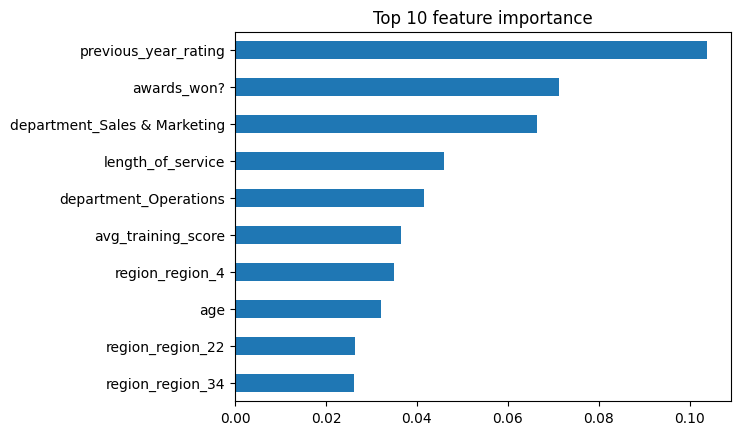

In [225]:
feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train_smote.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

feature_importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 feature importance")
plt.show()

todo: kratak tekst za feature importance

Analiza značaja atributa pokazuje da najveći uticaj na predikciju unapređenja zaposlenih imaju prethodna ocena rada (previous_year_rating) i osvajanje nagrada (awards_won?).

Ovo je očekivano, jer ovi atributi direktno reflektuju performanse zaposlenog.

Takođe, značajan uticaj imaju i organizacioni faktori kao što su pripadnost sektoru (department) i dužina radnog staža (length_of_service), što ukazuje na to da odluke o unapređenju zavise i od konteksta radnog mesta.

Manji uticaj imaju demografski atributi poput starosti (age), što sugeriše da unapređenje nije direktno povezano sa godinama zaposlenog.

- Najveći uticaj ima ocena performansi iz prethodne godine, što ukazuje da organizacija favorizuje zaposlene sa dokazanim rezultatima.
- Dobijene nagrade dodatno povećavaju verovatnoću unapređenja.
- Dužina radnog staža i broj treninga imaju umeren uticaj.
- Demografski atributi poput regiona i starosti imaju manji, ali primetan uticaj.

# SMOTEENN, pokusaj 4. metode banalsiranja, samo nad XGBoostom

Pored standardnih metoda balansiranja, testirana je i kombinovana metoda SMOTE-ENN, koja kombinuje oversampling i čišćenje podataka uklanjanjem šuma, sa ciljem poboljšanja kvaliteta trening skupa.

In [ ]:
smote_enn = SMOTEENN(random_state=42)
X_train_enn, y_train_enn = smote_enn.fit_resample(X_train, y_train)

xgb_enn = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=1.0,
    random_state=42,
    eval_metric='logloss'
)

xgb_enn.fit(X_train_enn, y_train_enn)

y_pred_enn = xgb_enn.predict(X_test)

print("Precision:", precision_score(y_test, y_pred_enn))
print("Recall:", recall_score(y_test, y_pred_enn))
print("F1:", f1_score(y_test, y_pred_enn))

Precision: 0.47572815533980584
Recall: 0.455
F1: 0.4651332603139832


Primena SMOTE-ENN metode dovodi do smanjenja f1-score vrednosti u odnosu na SMOTE. Iako ova metoda moze da ukloni sum iz podataka, moze dovesti i do gubitka korisnih instanci sto utice na performanse modela.

---
Classification report

In [227]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb_smote))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     15043
           1       0.80      0.36      0.50      1400

    accuracy                           0.94     16443
   macro avg       0.87      0.68      0.73     16443
weighted avg       0.93      0.94      0.93     16443



# Optimizacija, upotreba rezultata feature importance-a
Na osnovu analize značaja atributa izvršena je selekcija najrelevantnijih atributa, čime se smanjuje dimenzionalnost i poboljšava generalizacija modela.

In [230]:
top_features = feature_importance.head(10).index

X_train_fs = X_train_smote[top_features]
X_test_fs = X_test[top_features]

xgb_fs = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_fs.fit(X_train_fs, y_train_smote)

y_pred_fs = xgb_fs.predict(X_test_fs)

print("F1 pre:", f1_score(y_test, y_pred_xgb_smote))

print("F1:", f1_score(y_test, y_pred_fs))

F1 pre: 0.4975417895771878
F1: 0.42525252525252527


Nije povecalo f1-score

# Treshold tuning

In [232]:
y_proba = xgb_smote.predict_proba(X_test)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"Threshold {t} -> F1:", f1_score(y_test, y_pred_t))

Threshold 0.2 -> F1: 0.4130308318789994
Threshold 0.3 -> F1: 0.46957878315132606
Threshold 0.4 -> F1: 0.4884875846501129
Threshold 0.5 -> F1: 0.4975417895771878
Threshold 0.6 -> F1: 0.49560269011898606


Treshold 0.5 je sa najboljim rezultatom, to je i korisceno.

# Grid Search pokusaj 2.
bolji param grid? 
prosiren prostor pretrage

In [237]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

best_xgb2 = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.8}


## Evaluacija Grid Search 2 i xgboost i smote

In [238]:
y_pred_best = best_xgb2.predict(X_test)

print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))

Precision: 0.7760736196319018
Recall: 0.36142857142857143
F1: 0.49317738791423
